In [ ]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v25.dream_cytof.EGFR_MAPK")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "par_median_frob_norm", "par_dev_frob_norm", "_step"]
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
                # Frobenius norms of medians and deviations
                "par_median_frob_norm": row["par_median_frob_norm"],
                "par_dev_frob_norm": row["par_dev_frob_norm"],
            })

results_df = pd.DataFrame(all_rows)

In [ ]:
results_df.to_csv("results_05062025_Fabian.csv", index=False)

# Restart from here

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
results_df = pd.read_csv("results_05062025_Fabian.csv")
baseline_df = pd.read_csv("baseline_performance/baseline_regressors_rmse_newcv_newselect.csv")

# Subset to `features` used for scans

In [2]:
results_df = results_df[
    ((results_df.context == "cytof_init") & (results_df.features == "RFE_10_permute")) |
    ((results_df.context == "proteomics") & (results_df.features == "HVGRFE_20_permute")) |
    ((results_df.context == "transcriptomics") & (results_df.features.isin(["HVGRFE_15_permute", "HVGRFE_20_permute"])))
]

In [3]:
results_df.sort_values(by=["context", "samples", "features", "features_selection", "l1reg_inflater_output", "l2reg_inflater_output", "job", "step"], inplace=True)
baseline_df.sort_values(by=["context", "features", "features_selection", "dataset"], inplace=True)

In [7]:
def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

## Scan 1 - `l2reg_inflater_output` (`l1reg_inflater_output` == 1e3)

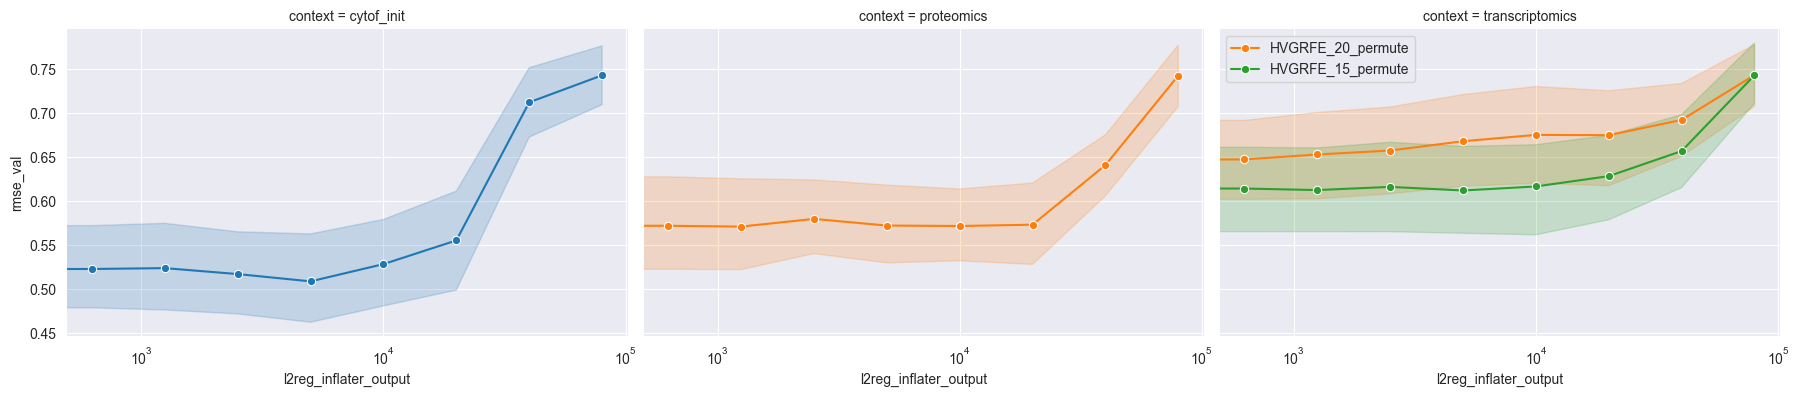

In [5]:
# Subset to final epoch (499) and l1reg_inflater_output == 1000 (central value for L2 reg scan)
l2reg_scan = results_df[(results_df.l1reg_inflater_output == 1000) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    l2reg_scan,
    col="context",
    col_order=sorted(l2reg_scan["context"].unique()),
    hue="features",
    hue_order=l2reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l2reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")
plt.legend()

Show trend across all `samples` -- almost perfectly consistent, apart from `transcriptomics` `3of5`.

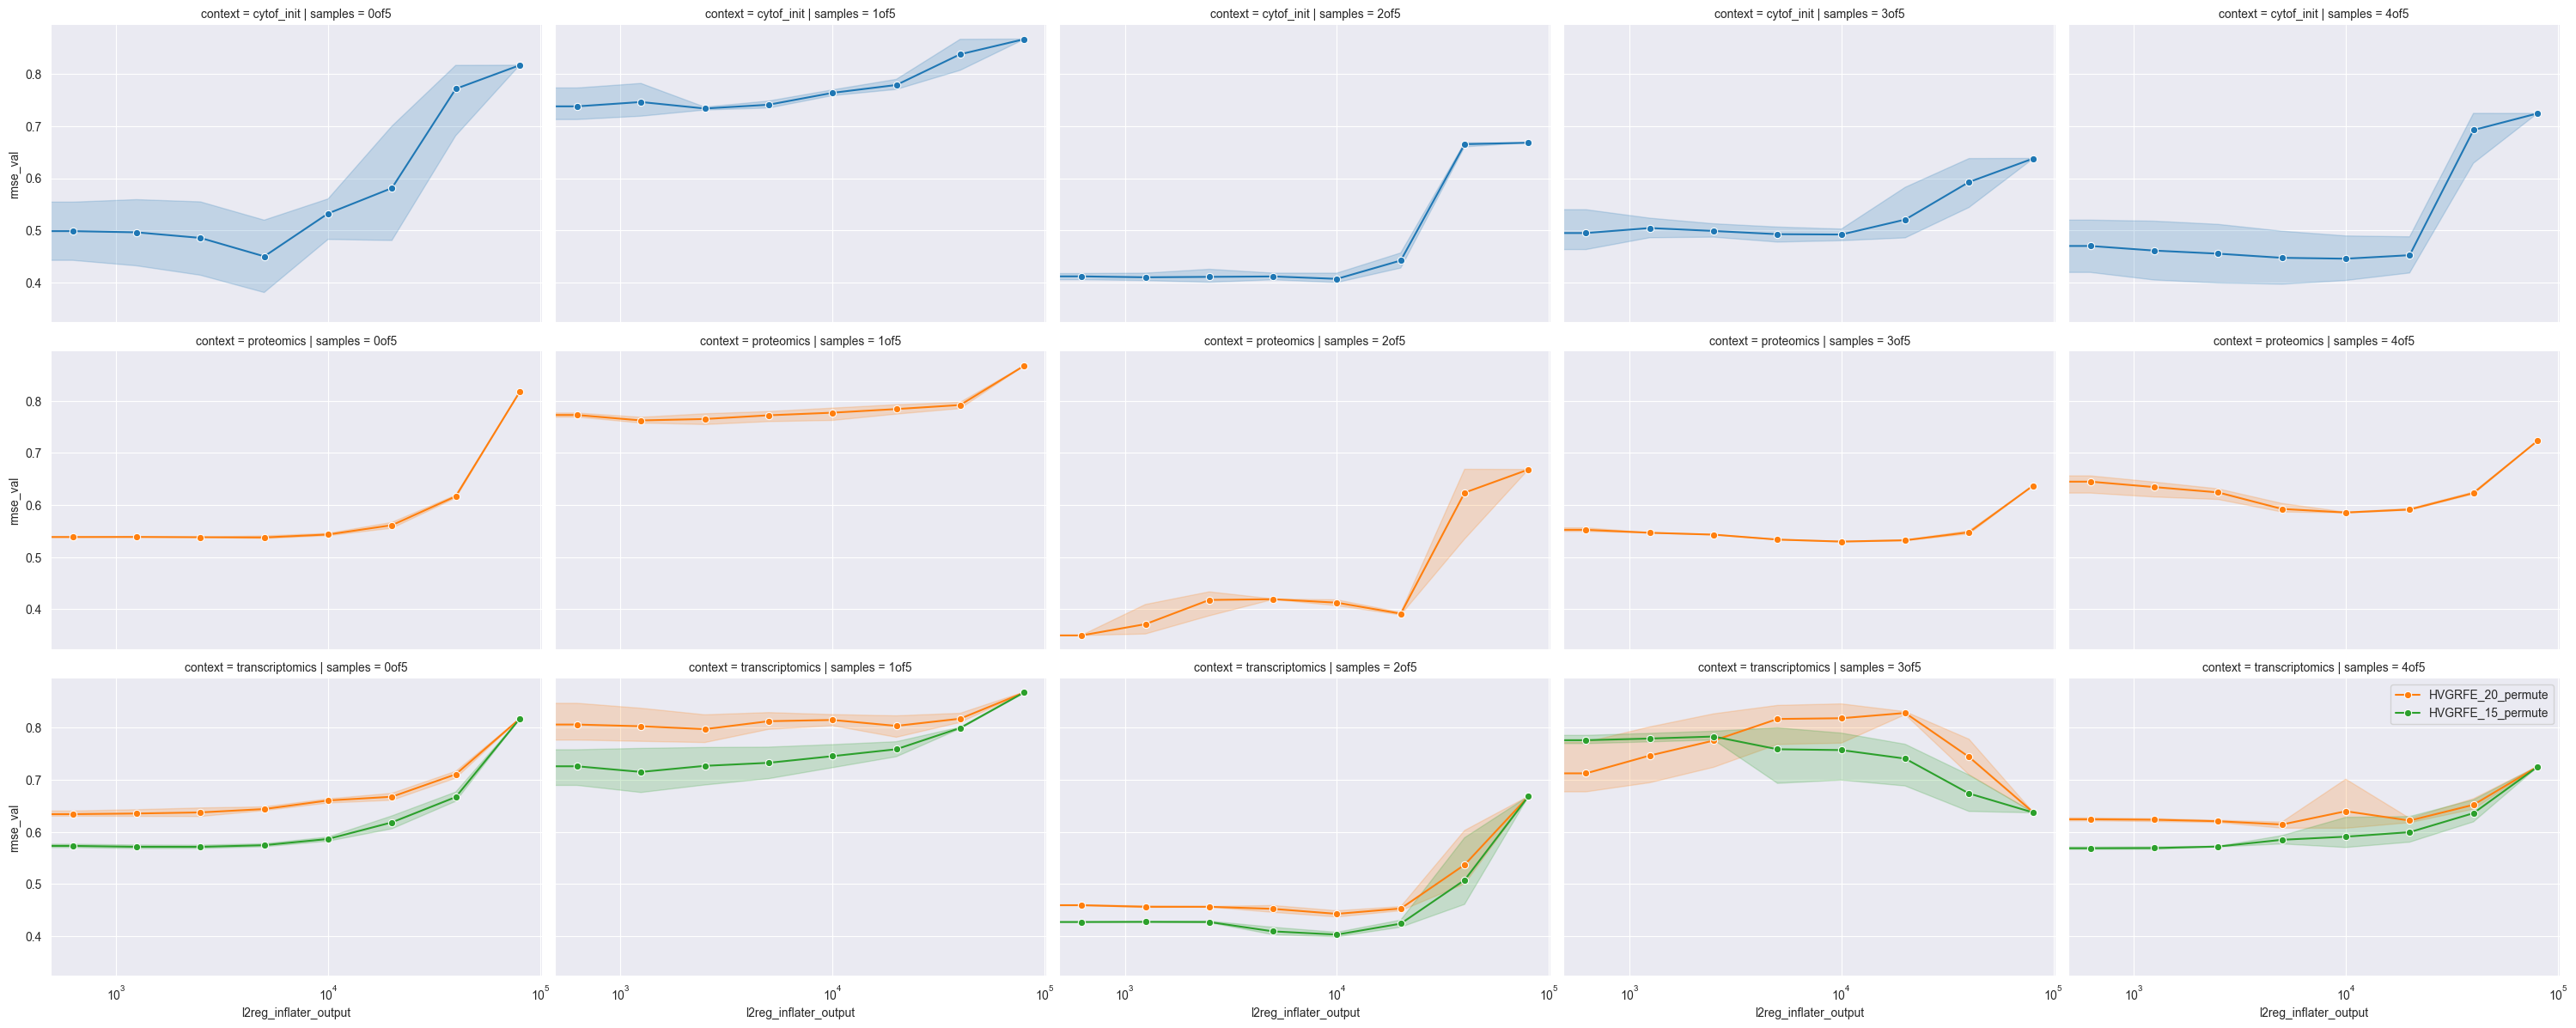

In [7]:
g = sns.FacetGrid(
    l2reg_scan,
    row="context",
    row_order=sorted(l2reg_scan["context"].unique()),
    col="samples",
    col_order=sorted(l2reg_scan["samples"].unique()),
    hue="features",
    hue_order=l2reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l2reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")
plt.legend()

Is there a statistically better `features` for `transcriptomics`? Yes, there is a statistically significant difference between `HVGRFE_15_permute` and `HVGRFE_20_permute` for `transcriptomics` context! (p-value < 0.05)

In [8]:
import scipy.stats as stats
kruskal_wallis_groups(
    l2reg_scan[l2reg_scan.context == "transcriptomics"],
    target_metric="rmse_val",
    group_metric="features"
)

Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=16.20, p-value=0.0001


<Axes: xlabel='l2reg_inflater_output', ylabel='rmse_val'>

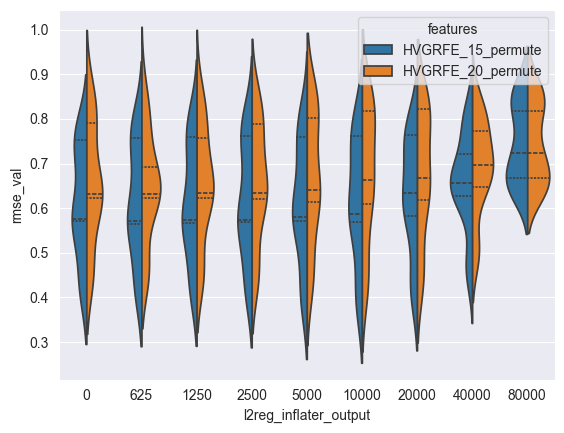

In [9]:
sns.violinplot(
    data=l2reg_scan[l2reg_scan.context == "transcriptomics"],
    x="l2reg_inflater_output",
    y="rmse_val",
    hue="features",
    split=True,
    inner="quartile",
    palette="tab10"
)

Is there any statistically better value of `l2reg_inflater_output` for each `context`? Clearly yes, but which one is it?

In [10]:
import scipy.stats as stats
kruskal_wallis_groups(
    l2reg_scan,
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=65.81, p-value=0.0000
Context: proteomics - Kruskal-Wallis H-test: H-statistic=45.07, p-value=0.0000
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=37.35, p-value=0.0000


# Scan 2 - `l1reg_inflater_output` with 2 options for `l2reg_inflater_output` (0, 1e4)

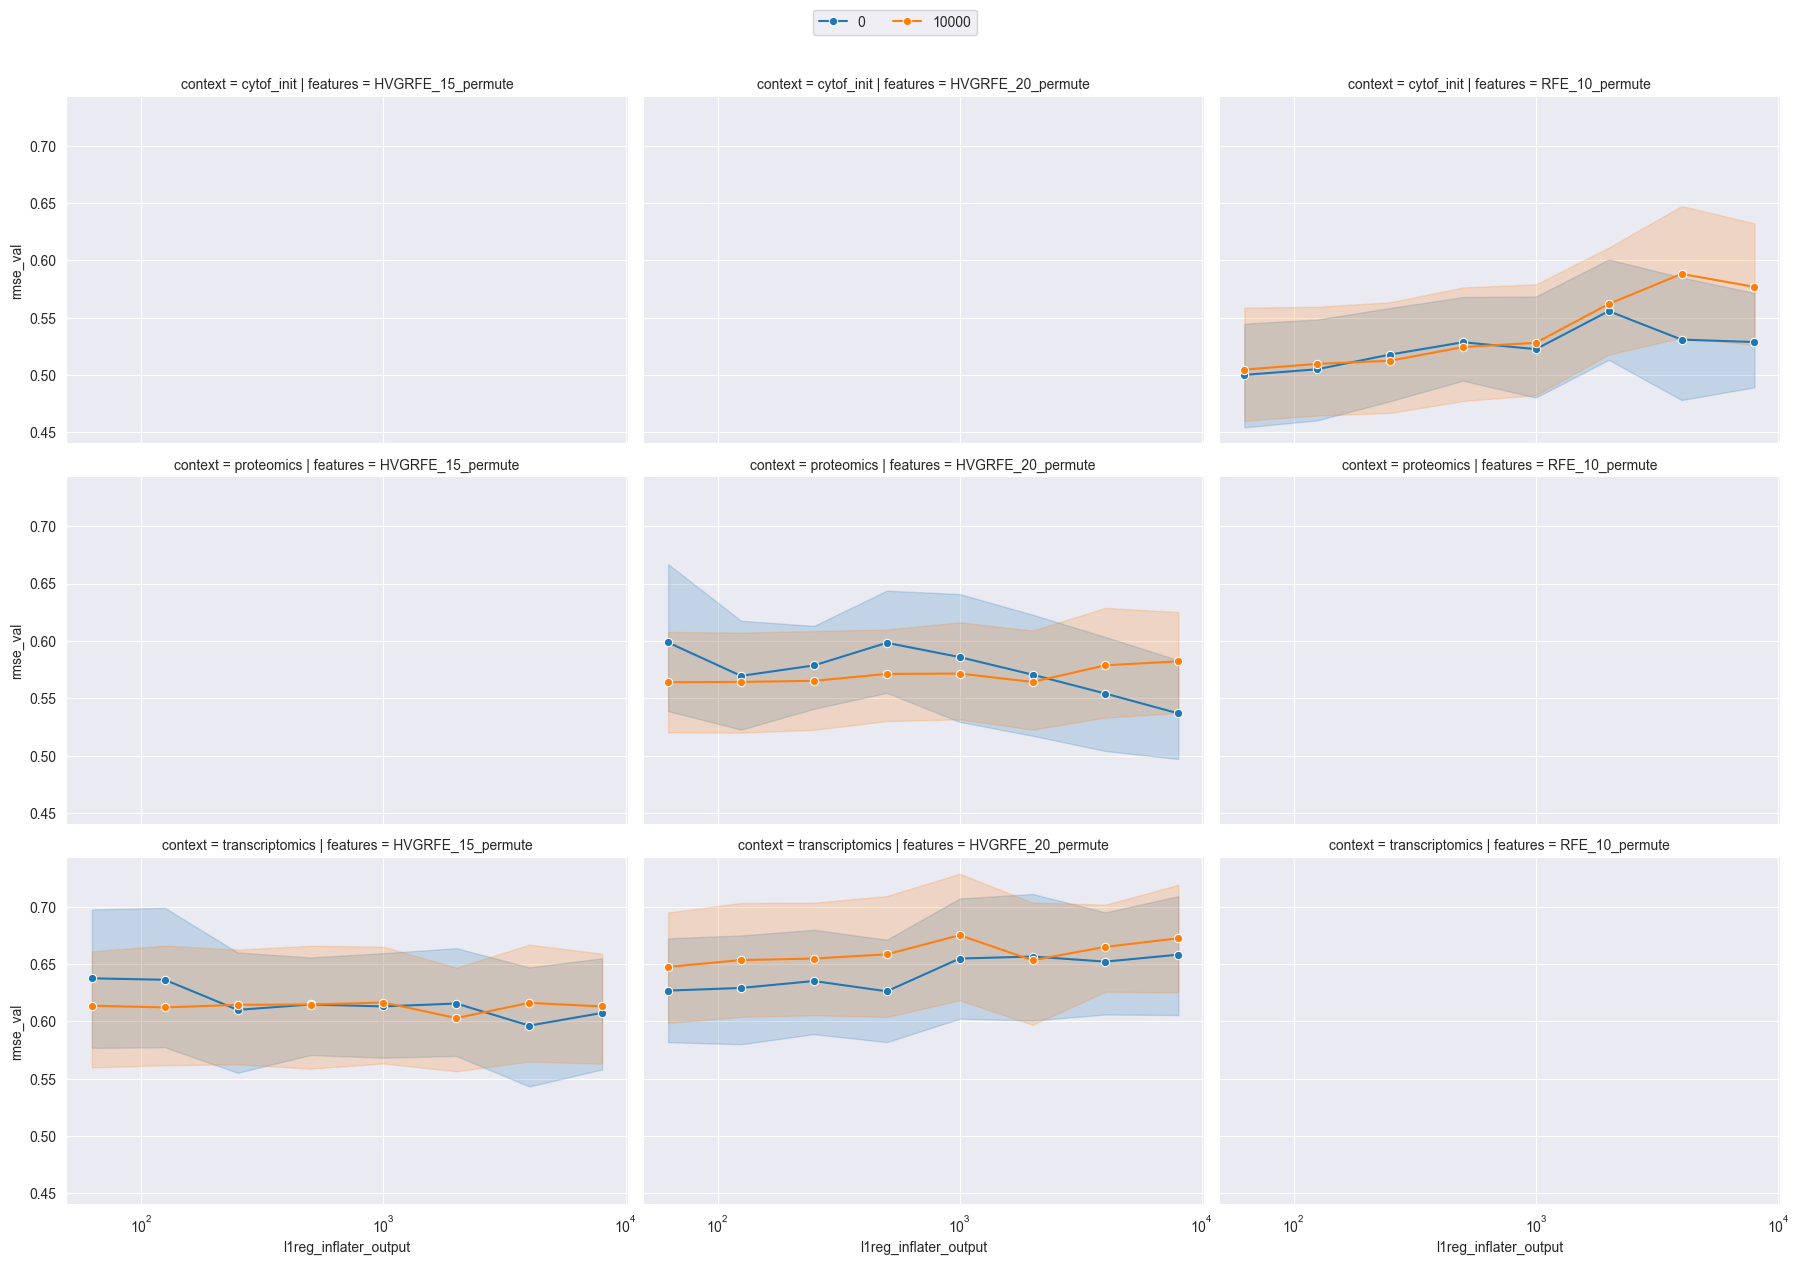

In [11]:
l1reg_scan = results_df[(results_df.l2reg_inflater_output.isin([0, 1e4])) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    l1reg_scan,
    col="features",
    col_order=sorted(l1reg_scan["features"].unique()),
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    hue="l2reg_inflater_output",
    hue_order=sorted(l1reg_scan.l2reg_inflater_output.unique()),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l1reg_inflater_output",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("log")

# Find an axis with data and draw the legend from that
for ax in g.axes.flat:
    if len(ax.lines) > 0:
        handles, labels = ax.get_legend_handles_labels()
        g._legend = g.figure.legend(
            handles, labels,
            loc='upper center', ncol=len(labels),
            bbox_to_anchor=(0.5, 1.05)
        )
        break

Is there a difference between not using and using `l2reg_inflater_output` in each context? Not in `cytof_init` or `proteomics`, either if looking at all values or only those above 2000. Not even in `transcriptomics`, for either `features`. If anything, the lowest values are achieved with no `l2reg_inflater_output` in all cases.

In [12]:
kruskal_wallis_groups(
    l1reg_scan[l1reg_scan.context == "cytof_init"],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "cytof_init") & (l1reg_scan.l1reg_inflater_output > 2000)],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.14, p-value=0.7080
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=3.52, p-value=0.0608


In [13]:
kruskal_wallis_groups(
    l1reg_scan[l1reg_scan.context == "proteomics"],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "proteomics") & (l1reg_scan.l1reg_inflater_output > 2000)],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: proteomics - Kruskal-Wallis H-test: H-statistic=0.47, p-value=0.4942
Context: proteomics - Kruskal-Wallis H-test: H-statistic=3.26, p-value=0.0709


In [14]:
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "transcriptomics") & (l1reg_scan.features == "HVGRFE_15_permute")],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context == "transcriptomics") & (l1reg_scan.features == "HVGRFE_20_permute")],
    target_metric="rmse_val",
    group_metric="l2reg_inflater_output"
)

Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9311
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=1.64, p-value=0.2002


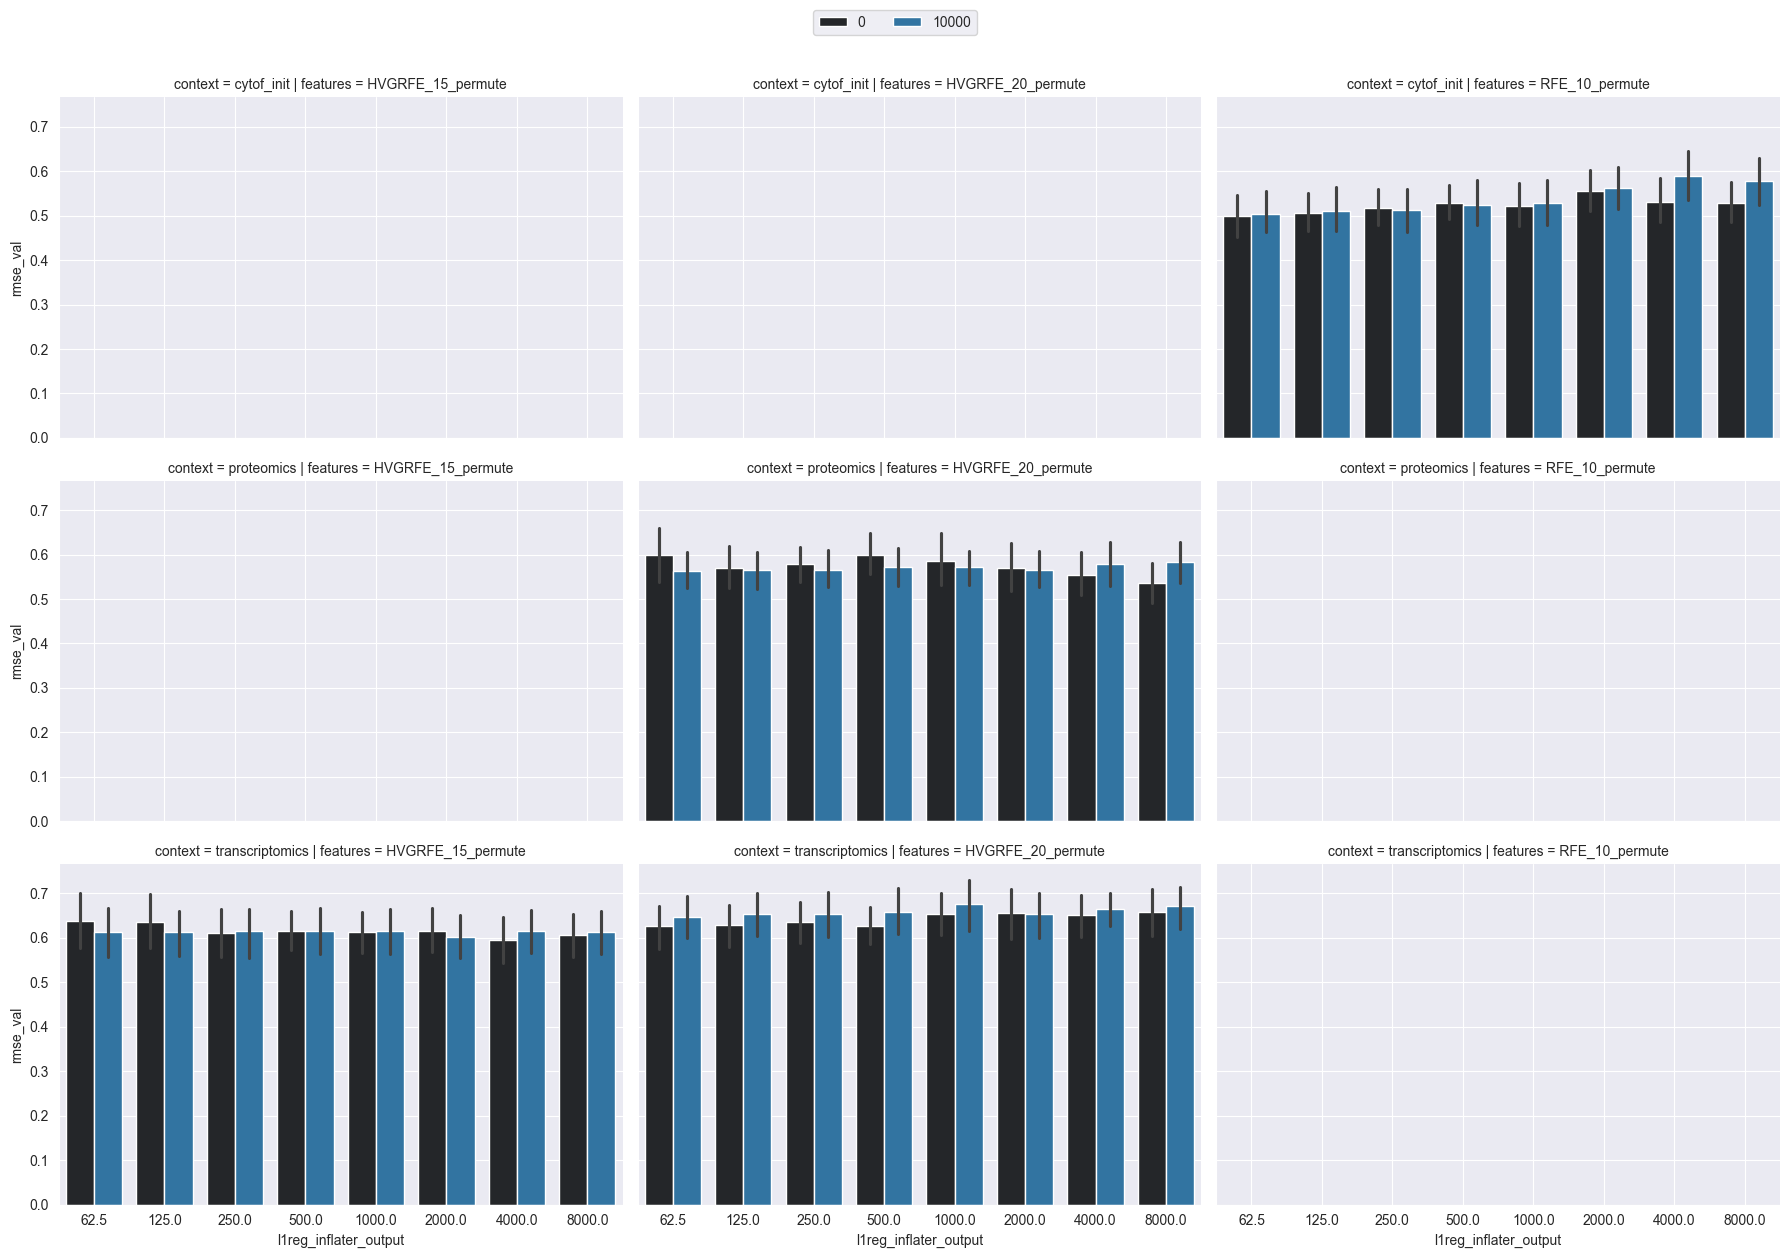

In [17]:
g = sns.FacetGrid(
    l1reg_scan,
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    col="features",
    col_order=sorted(l1reg_scan["features"].unique()),
    height=4,
    aspect=1.5
)

g.map_dataframe(
    sns.barplot,
    x="l1reg_inflater_output",
    y="rmse_val",
    hue="l2reg_inflater_output",
    hue_order=sorted(l1reg_scan.l2reg_inflater_output.unique()),
    #split=True,
)

# Find an axis with data and draw the legend from that
for ax in g.axes.flat:
    if len(ax.lines) > 0:
        handles, labels = ax.get_legend_handles_labels()
        g._legend = g.figure.legend(
            handles, labels,
            loc='upper center', ncol=len(labels),
            bbox_to_anchor=(0.5, 1.05)
        )
        break


The best options seem to be: 62.5 `l1` and 0 `l2` for `cytof_init`, 8000 `l1` and 0 `l2` for `proteomics`, and 4000 `l1` and 0 `l2` for `transcriptomics` with `HVGRFE_15_permute` `features`.

In [22]:
agg_rmse = (
    l1reg_scan
    .groupby(['context', 'features', 'l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
    .mean()
    .reset_index()
)

best_combos = (
    agg_rmse
    .groupby(['context', 'features'])
    .apply(lambda df: df.loc[df['rmse_val'].idxmin()])
    .reset_index(drop=True)
)

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_90472/3584228608.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.loc[df['rmse_val'].idxmin()])


In [23]:
best_combos

,context,features,l1reg_inflater_output,l2reg_inflater_output,rmse_val
0,cytof_init,RFE_10_permute,62.5,0,0.500144
1,proteomics,HVGRFE_20_permute,8000.0,0,0.536806
2,transcriptomics,HVGRFE_15_permute,4000.0,0,0.596328
3,transcriptomics,HVGRFE_20_permute,500.0,0,0.626255


The best combinations are not statistically better according to Kruskal-Wallis test

In [27]:
from scipy.stats import kruskal

results = []

grouped_by_cf = l1reg_scan.groupby(['context', 'features'])

for (ctx, feat), group in grouped_by_cf:
    # Create rmse lists grouped by (l1, l2)
    grouped_rmse = (
        group
        .groupby(['l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
        .apply(list)
    )

    # Check we have at least two groups to compare
    if len(grouped_rmse) < 2:
        continue

    try:
        # Pass unpacked list of lists to kruskal
        stat, pval = kruskal(*grouped_rmse.values)

        # Find best combo based on mean rmse
        means = grouped_rmse.apply(lambda x: sum(x)/len(x))
        best_combo = means.idxmin()

        results.append({
            'context': ctx,
            'features': feat,
            'best_l1': best_combo[0],
            'best_l2': best_combo[1],
            'kruskal_stat': stat,
            'kruskal_pval': pval,
            'n_comparisons': len(grouped_rmse)
        })
    except Exception as e:
        print(f"Failed on ({ctx}, {feat}): {e}")


In [28]:
results

[{'context': 'cytof_init',
  'features': 'RFE_10_permute',
  'best_l1': 62.5,
  'best_l2': 0,
  'kruskal_stat': 20.028365087281827,
  'kruskal_pval': 0.17084726866796526,
  'n_comparisons': 16},
 {'context': 'proteomics',
  'features': 'HVGRFE_20_permute',
  'best_l1': 8000.0,
  'best_l2': 0,
  'kruskal_stat': 5.840831108620779,
  'kruskal_pval': 0.982299076538513,
  'n_comparisons': 16},
 {'context': 'transcriptomics',
  'features': 'HVGRFE_15_permute',
  'best_l1': 4000.0,
  'best_l2': 0,
  'kruskal_stat': 3.8413107231920094,
  'kruskal_pval': 0.9982122195434034,
  'n_comparisons': 16},
 {'context': 'transcriptomics',
  'features': 'HVGRFE_20_permute',
  'best_l1': 500.0,
  'best_l2': 0,
  'kruskal_stat': 6.56634014962583,
  'kruskal_pval': 0.9685865670318009,
  'n_comparisons': 16}]

but at least `proteomics` is statistically significant using mixed effects model

In [25]:
import statsmodels.formula.api as smf

results = []

for (ctx, feat), group in l1reg_scan.groupby(['context', 'features']):
    group = group.copy()
    group['combo'] = group['l1reg_inflater_output'].astype(str) + "_" + group['l2reg_inflater_output'].astype(str)

    model = smf.mixedlm("rmse_val ~ combo", group, groups=group["samples"])
    result = model.fit()

    best_combo = (
        group.groupby(['l1reg_inflater_output', 'l2reg_inflater_output'])['rmse_val']
        .mean()
        .idxmin()
    )

    results.append({
        'context': ctx,
        'features': feat,
        'best_l1': best_combo[0],
        'best_l2': best_combo[1],
        'model_pval': result.pvalues.get('combo[T.' + '_'.join(map(str, best_combo)) + ']', None),
        'summary': result.summary().as_text()
    })


In [26]:
results

[{'context': 'cytof_init',
  'features': 'RFE_10_permute',
  'best_l1': 62.5,
  'best_l2': 0,
  'model_pval': 0.18406202143189598,
  'summary': '             Mixed Linear Model Regression Results\n================================================================\nModel:                MixedLM    Dependent Variable:    rmse_val\nNo. Observations:     400        Method:                REML    \nNo. Groups:           5          Scale:                 0.0036  \nMin. group size:      80         Log-Likelihood:        499.9024\nMax. group size:      80         Converged:             Yes     \nMean group size:      80.0                                      \n----------------------------------------------------------------\n                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]\n----------------------------------------------------------------\nIntercept              0.523    0.054  9.607 0.000  0.416  0.629\ncombo[T.1000.0_10000]  0.006    0.017  0.328 0.743 -0.028  0.039\ncombo[T.125

In [83]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v26.dream_cytof.EGFR_MAPK")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")
    l1reg_encode = run.config.get("l1reg_encode")
    oreg_encode = run.config.get("oreg_encode")
    l1reg_inflate = run.config.get("l1reg_inflate")
    oreg_inflate = run.config.get("oreg_inflate")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "par_median_frob_norm", "par_dev_frob_norm", "_step"]
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                "l1reg_encode": l1reg_encode,
                "oreg_encode": oreg_encode,
                "l1reg_inflate": l1reg_inflate,
                "oreg_inflate": oreg_inflate,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
                # Frobenius norms of medians and deviations
                "par_median_frob_norm": row["par_median_frob_norm"],
                "par_dev_frob_norm": row["par_dev_frob_norm"],
            })

results_df = pd.DataFrame(all_rows)

100%|██████████| 3755/3755 [46:40<00:00,  1.34it/s]


In [183]:
results_df.to_csv("results_all_contexts_10062025.csv", index=False)

}Reload

In [55]:
results_df = pd.read_csv("results_all_contexts_10062025.csv")


In [56]:
results_df

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,l1reg_encode,oreg_encode,l1reg_inflate,oreg_inflate,step,rmse_train,rmse_val,par_median_frob_norm,par_dev_frob_norm
0,cytof_init,1of5,2,0,RFE_10_permute,NaN,6,62.5,100,0,gmm,4000.0,0.0,4000.0,0.0,1,0.596206,0.700060,8.740571,5.028728
1,cytof_init,1of5,2,0,RFE_10_permute,NaN,6,62.5,100,0,gmm,4000.0,0.0,4000.0,0.0,13,0.534180,0.941970,8.695907,0.097018
2,cytof_init,1of5,2,0,RFE_10_permute,NaN,6,62.5,100,0,gmm,4000.0,0.0,4000.0,0.0,26,0.526865,0.829783,8.683927,0.044496
3,cytof_init,1of5,2,0,RFE_10_permute,NaN,6,62.5,100,0,gmm,4000.0,0.0,4000.0,0.0,36,0.524090,0.896800,8.657882,0.018462
4,cytof_init,1of5,2,0,RFE_10_permute,NaN,6,62.5,100,0,gmm,4000.0,0.0,4000.0,0.0,50,0.522580,0.854395,8.620128,0.008369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44976,transcriptomics,2of5,2,0,HVGRFE_15_permute,NaN,3,4000.0,100,0,gmm,4000.0,0.0,4000.0,0.0,135,0.523211,0.659936,8.743279,0.001398
44977,transcriptomics,2of5,2,0,HVGRFE_15_permute,NaN,3,4000.0,100,0,gmm,4000.0,0.0,4000.0,0.0,187,0.519456,0.663066,8.794235,0.001274
44978,transcriptomics,2of5,2,0,HVGRFE_15_permute,NaN,3,4000.0,100,0,gmm,4000.0,0.0,4000.0,0.0,259,0.515867,0.666681,8.639115,0.002331
44979,transcriptomics,2of5,2,0,HVGRFE_15_permute,NaN,3,4000.0,100,0,gmm,4000.0,0.0,4000.0,0.0,360,0.514418,0.668286,9.177474,0.002394


# L1 reg scan

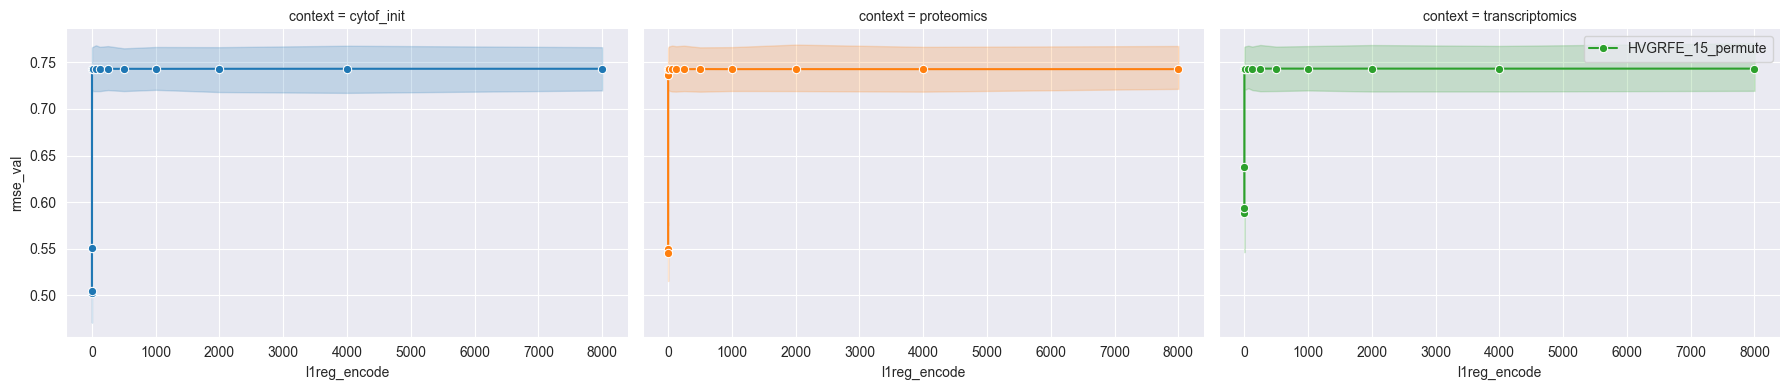

In [4]:
# Subset to final epoch (499) and no orhogonal regularisation (oreg_encode == 0)
l1reg_scan = results_df[(results_df.oreg_encode == 0) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    l1reg_scan,
    col="context",
    col_order=sorted(l1reg_scan["context"].unique()),
    hue="features",
    hue_order=l1reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l1reg_encode",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

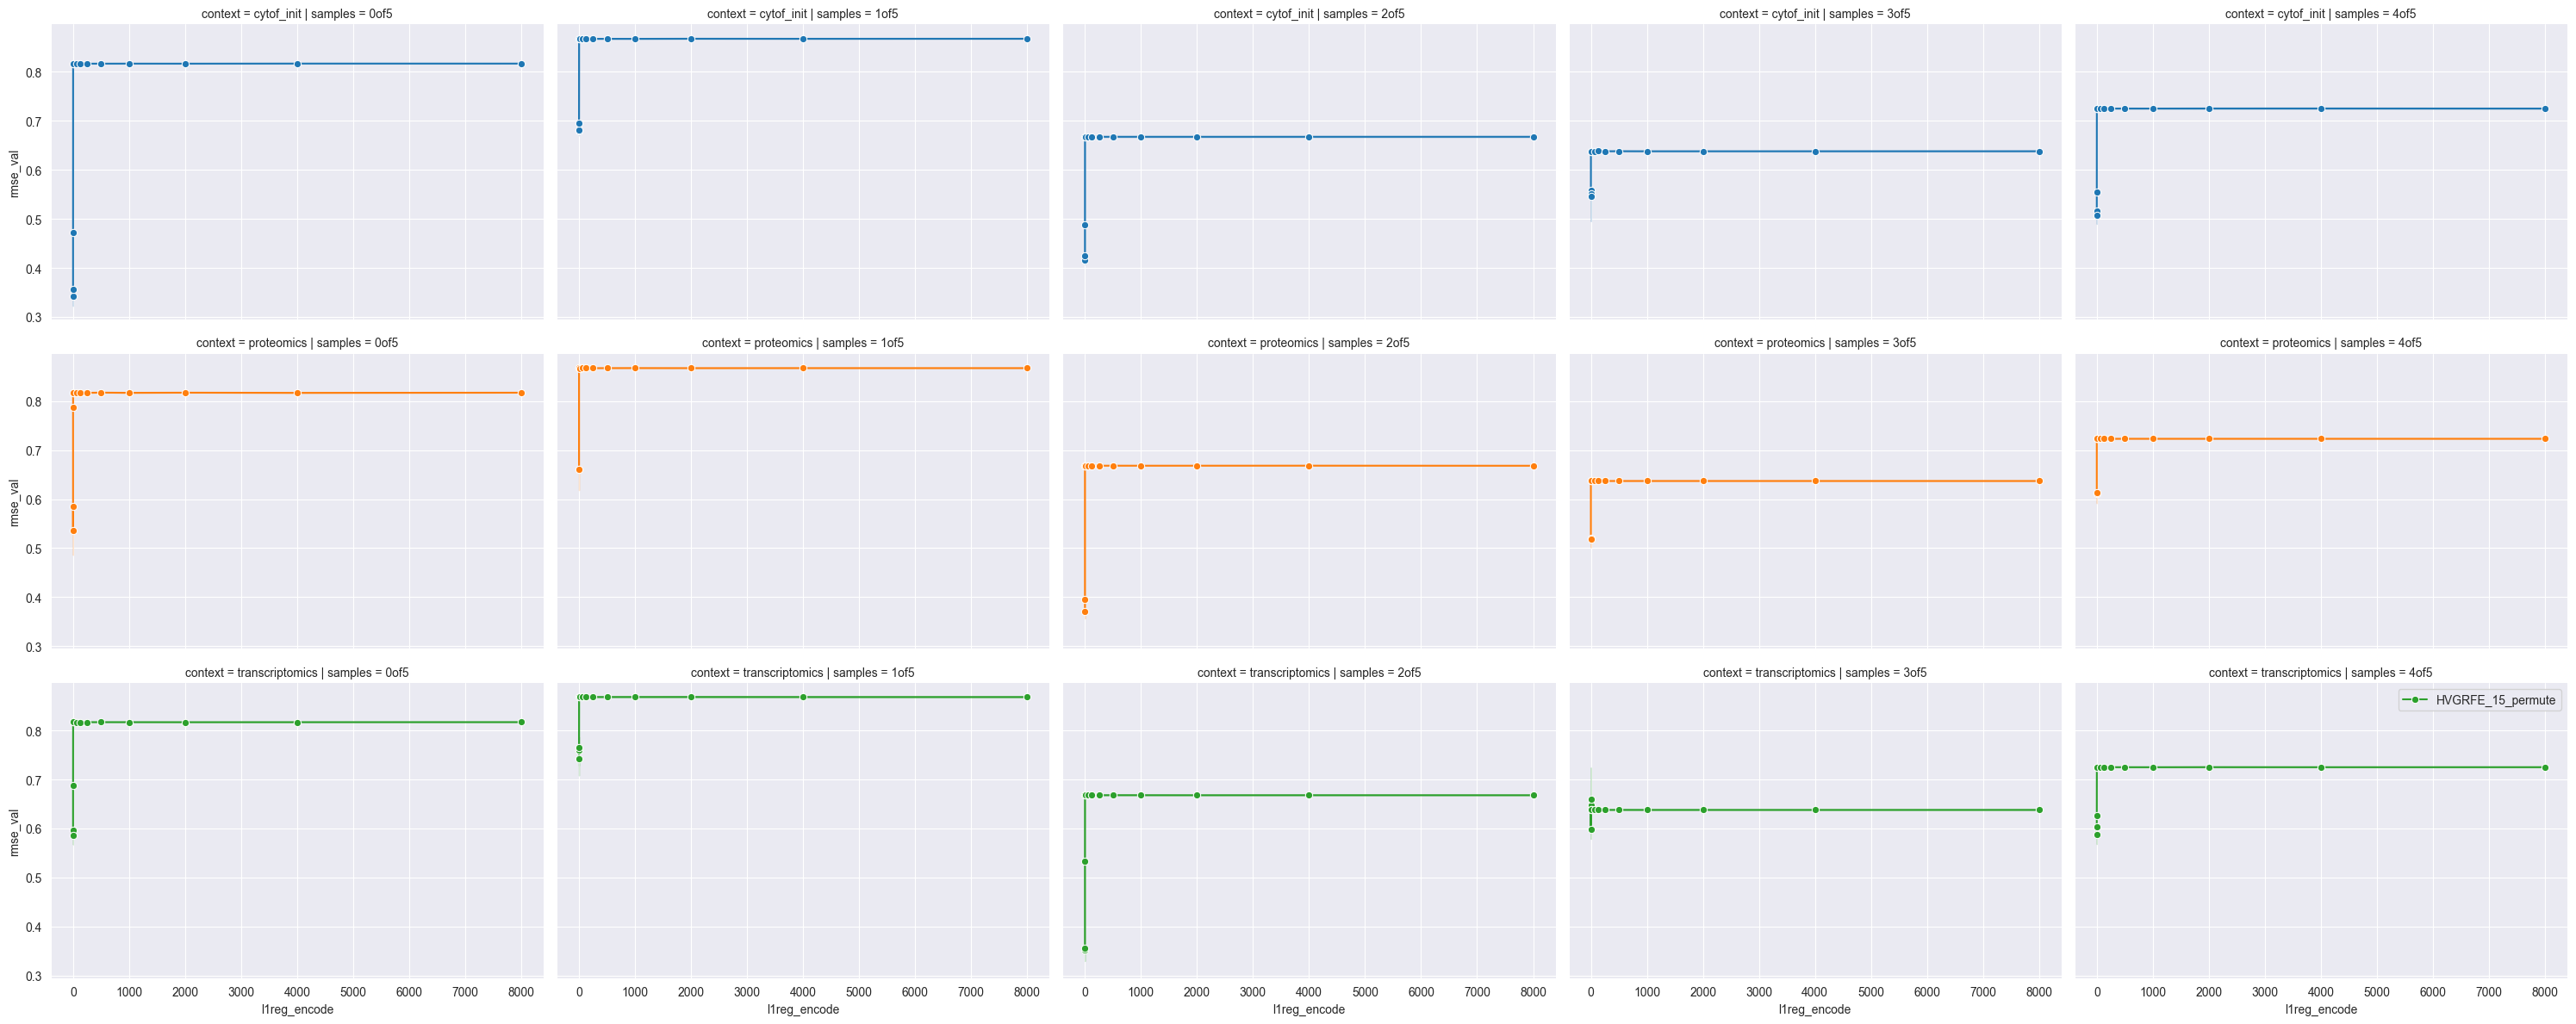

In [5]:
# Subset to final epoch (499) and no orhogonal regularisation (oreg_encode == 0)
g = sns.FacetGrid(
    l1reg_scan,
    col="samples",
    col_order=sorted(l1reg_scan["samples"].unique()),
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    hue="features",
    hue_order=l1reg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="l1reg_encode",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

In [8]:
import scipy.stats as stats
kruskal_wallis_groups(
    l1reg_scan,
    target_metric="rmse_val",
    group_metric="l1reg_encode"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=245.25, p-value=0.0000
Context: proteomics - Kruskal-Wallis H-test: H-statistic=176.47, p-value=0.0000
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=154.93, p-value=0.0000


<Figure size 1200x1200 with 0 Axes>

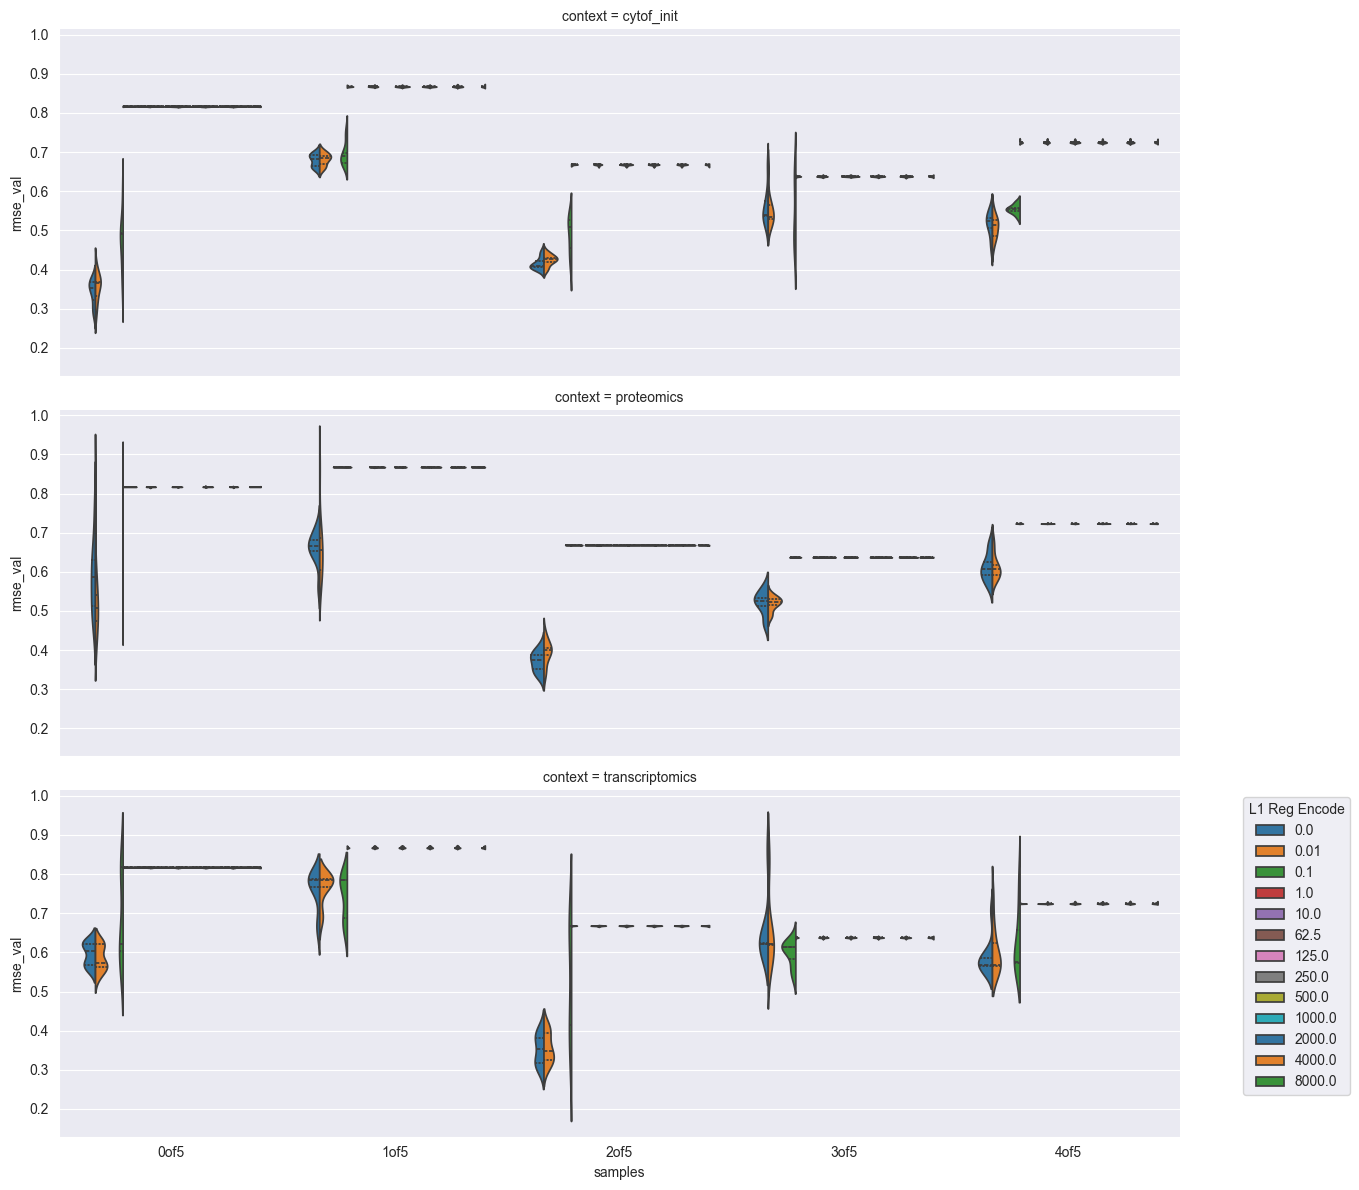

In [9]:
plt.figure(figsize=(12, 12))
g = sns.FacetGrid(
    l1reg_scan,
    row="context",
    row_order=sorted(l1reg_scan["context"].unique()),
    height=4,
    aspect=3
)
g.map_dataframe(
    sns.violinplot,
    x="samples",
    order=sorted(l1reg_scan["samples"].unique()),
    y="rmse_val",
    hue="l1reg_encode",
    split=True,
    inner="quartile",
    palette="tab10"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="L1 Reg Encode")

## Is there any statistical difference between 0 and 0.01 `l1reg_encode`? No, but it does not look like it's helping either. Potentially helping in `4of5` but making `2of5` worse.

In [18]:
kruskal_wallis_groups(
    l1reg_scan[l1reg_scan.l1reg_encode.isin([0, 0.01])],
    target_metric="rmse_val",
    group_metric="l1reg_encode"
)
print("=== Restricting to cytof_init and transcriptomics, l1reg_encode in [0, 0.01, 0.1] ===")
kruskal_wallis_groups(
    l1reg_scan[(l1reg_scan.context.isin(["cytof_init", "transcriptomics"]) & (l1reg_scan.l1reg_encode.isin([0, 0.01, 0.1])))],
    target_metric="rmse_val",
    group_metric="l1reg_encode"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.00, p-value=0.9615
Context: proteomics - Kruskal-Wallis H-test: H-statistic=0.30, p-value=0.5860
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9286
=== Restricting to cytof_init and transcriptomics, l1reg_encode in [0, 0.01, 0.1] ===
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=5.86, p-value=0.0535
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=3.48, p-value=0.1753


In [19]:
l1reg_scan.groupby(['context', 'samples', 'l1reg_encode'])['rmse_val'].mean().reset_index().sort_values(['samples', 'l1reg_encode'])

,context,samples,l1reg_encode,rmse_val
0,cytof_init,0of5,0.00,0.342532
65,proteomics,0of5,0.00,0.584935
130,transcriptomics,0of5,0.00,0.595788
1,cytof_init,0of5,0.01,0.355650
66,proteomics,0of5,0.01,0.535876
...,...,...,...,...
128,proteomics,4of5,4000.00,0.723276
193,transcriptomics,4of5,4000.00,0.725094
64,cytof_init,4of5,8000.00,0.725191
129,proteomics,4of5,8000.00,0.723288


# Oreg scan

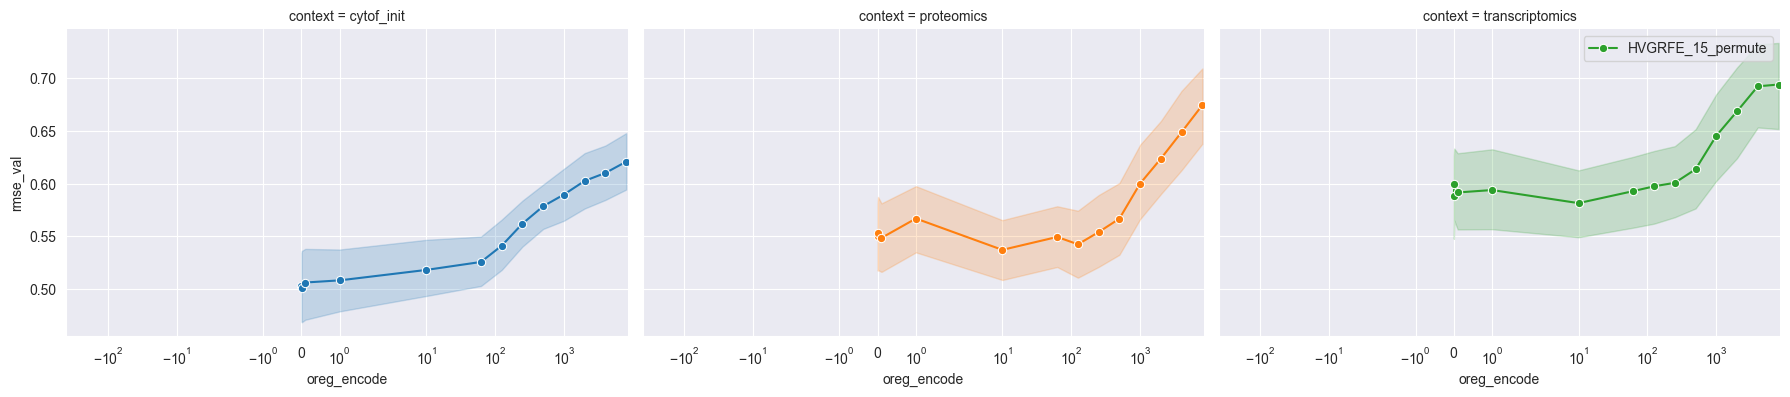

In [20]:
# Subset to final epoch (499) and no L1 regularisation (l1reg_encode == 0)
oreg_scan = results_df[(results_df.l1reg_encode == 0) & (results_df.step == results_df.step.max())]

g = sns.FacetGrid(
    oreg_scan,
    col="context",
    col_order=sorted(oreg_scan["context"].unique()),
    hue="features",
    hue_order=oreg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="oreg_encode",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("symlog")
plt.legend()

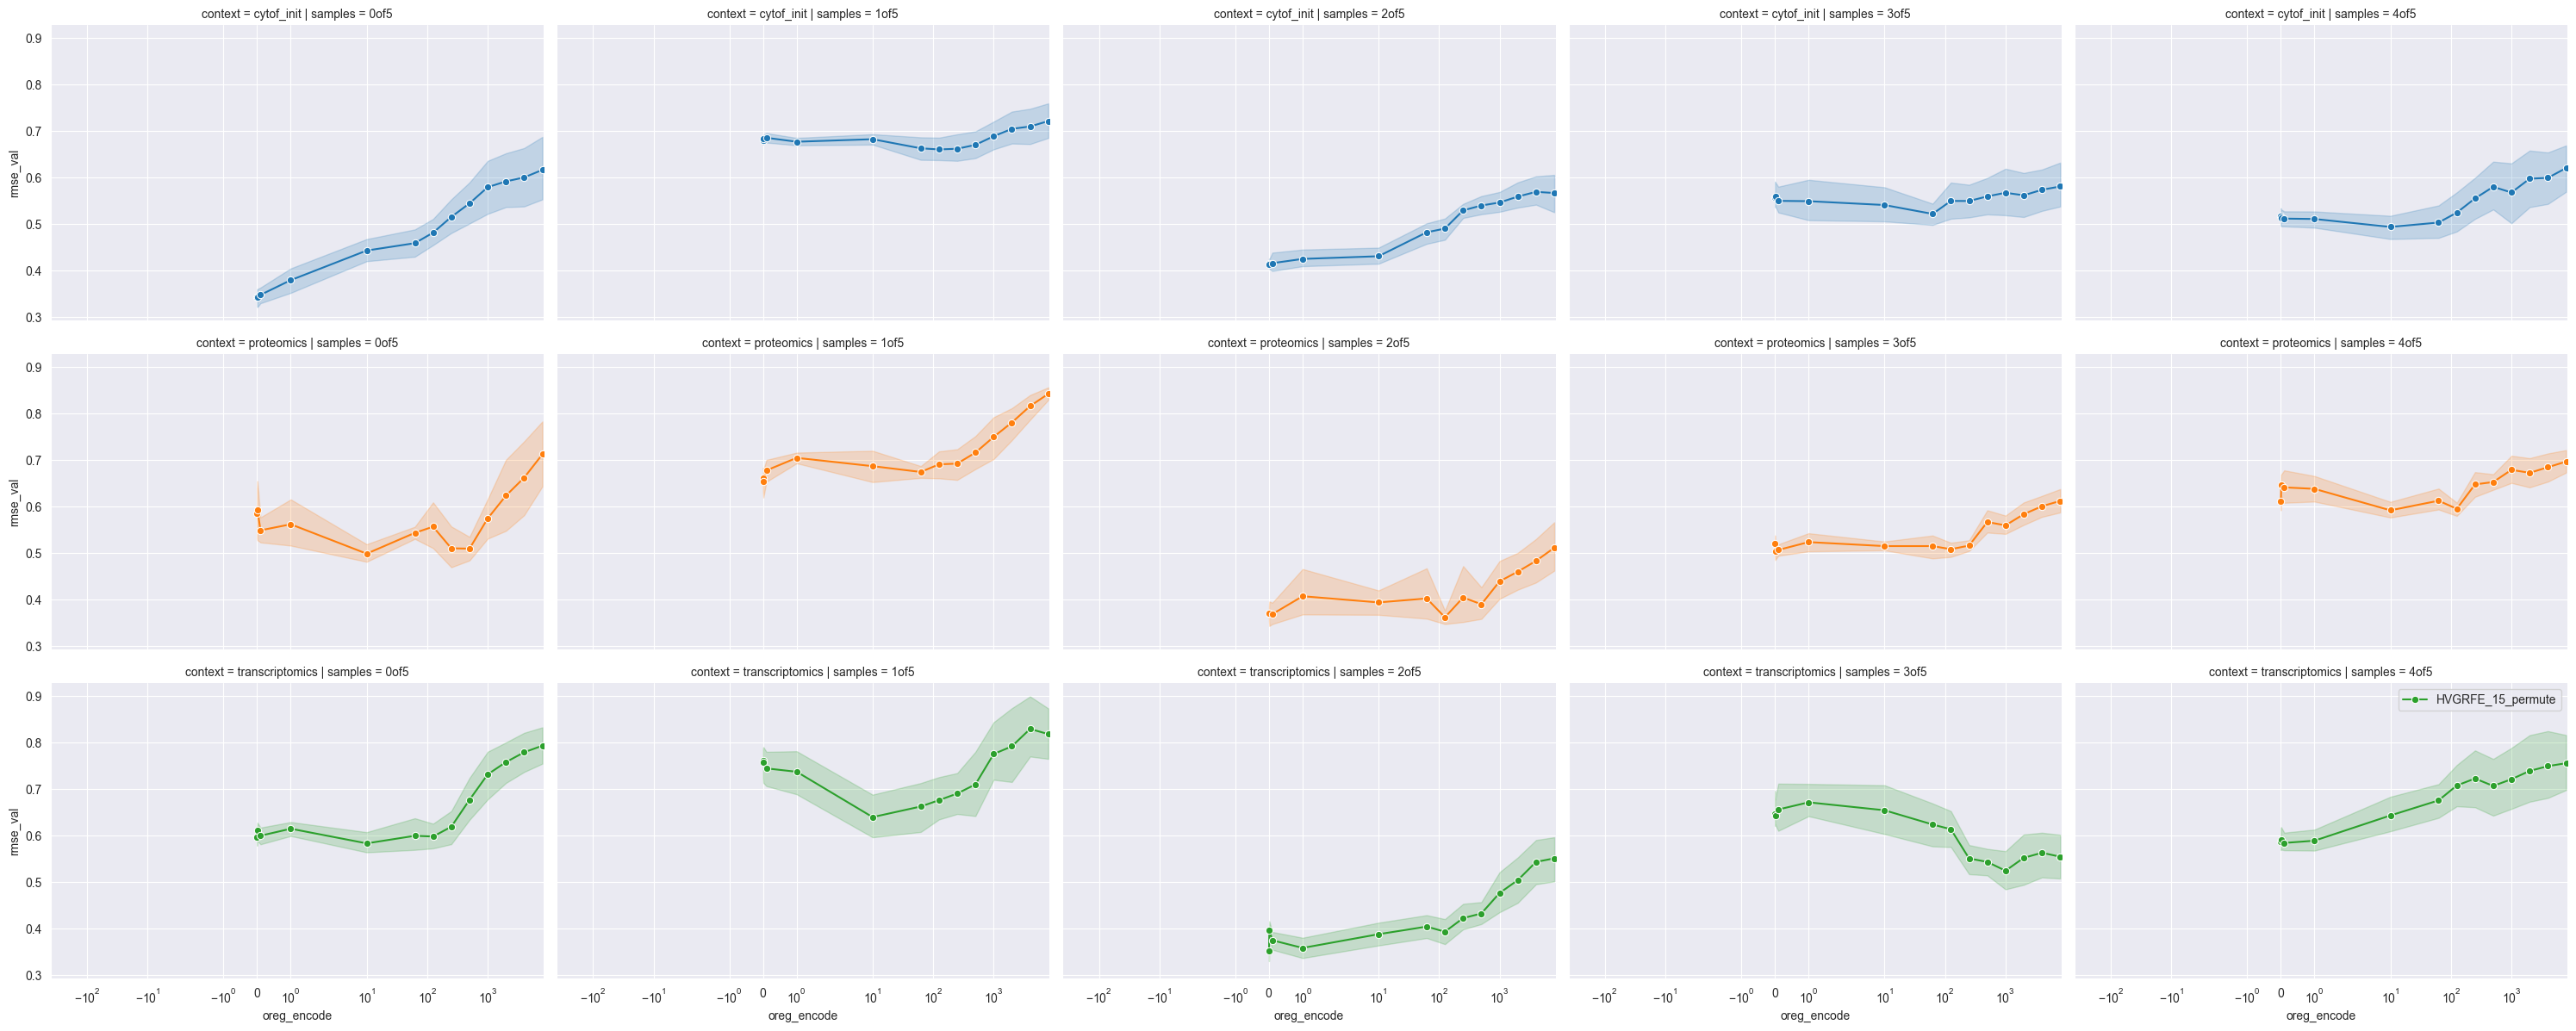

In [21]:
# Subset to final epoch (499) and no L1 regularisation (l1reg_encode == 0)
g = sns.FacetGrid(
    oreg_scan,
    col="samples",
    col_order=sorted(oreg_scan["samples"].unique()),
    row="context",
    row_order=sorted(oreg_scan["context"].unique()),
    hue="features",
    hue_order=oreg_scan.features.unique(),
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="oreg_encode",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.xscale("symlog")
plt.legend()

<Figure size 1200x600 with 0 Axes>

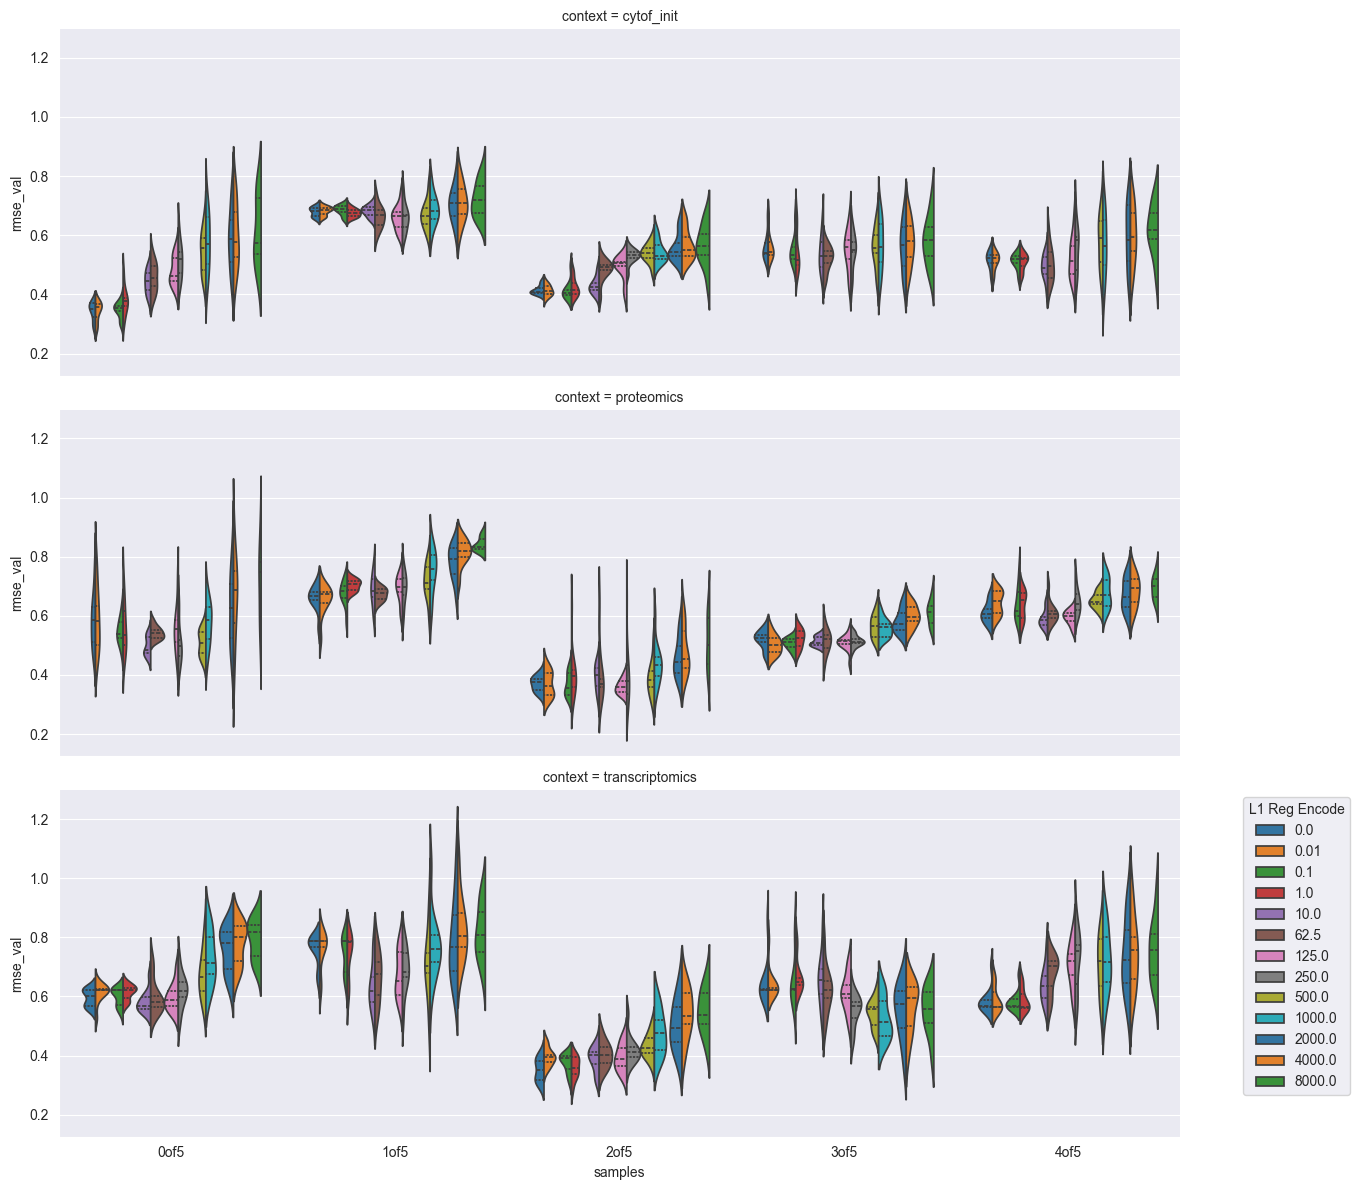

In [22]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(
    oreg_scan,
    row="context",
    row_order=sorted(oreg_scan["context"].unique()),
    height=4,
    aspect=3
)
g.map_dataframe(
    sns.violinplot,
    x="samples",
    order=sorted(oreg_scan["samples"].unique()),
    y="rmse_val",
    hue="oreg_encode",
    split=True,
    inner="quartile",
    palette="tab10"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="L1 Reg Encode")

## There is a statistically significant difference across the entire range of values, but this does not exist when we look at values below 62.5, which is the optimal value for some sample splits.

In [206]:
kruskal_wallis_groups(
    oreg_scan[oreg_scan.oreg_encode < 62.5],
    target_metric="rmse_val",
    group_metric="oreg_encode"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.52, p-value=0.9715
Context: proteomics - Kruskal-Wallis H-test: H-statistic=2.46, p-value=0.6514
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=1.28, p-value=0.8645


# Overall outcome: no statistically significant difference (consistent across `samples`) between using/not using low values of regularisation - we can drop it in both `cytof_init` and `proteomics`.

In [23]:
# Find best configuration per context
agg_rmse = (
    oreg_scan
    .groupby(['context', 'l1reg_encode', 'oreg_encode'])['rmse_val']
    .mean()
    .reset_index()
)
best_combos = (
    agg_rmse
    .groupby(['context'])
    .apply(lambda df: df.loc[df['rmse_val'].idxmin()])
    .reset_index(drop=True)
)
best_combos

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_50750/1879468269.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.loc[df['rmse_val'].idxmin()])


,context,l1reg_encode,oreg_encode,rmse_val
0,cytof_init,0.0,0.01,0.501269
1,proteomics,0.0,10.00,0.537076
2,transcriptomics,0.0,10.00,0.581479


In [24]:
agg_rmse[(agg_rmse.l1reg_encode == 0) & (agg_rmse.oreg_encode == 0)].sort_values(
    ["context", "rmse_val"]
)

,context,l1reg_encode,oreg_encode,rmse_val
0,cytof_init,0.0,0.0,0.502362
13,proteomics,0.0,0.0,0.549826
26,transcriptomics,0.0,0.0,0.588437


In [25]:
no_reg = results_df[
    (results_df.l1reg_encode == 0) &
    (results_df.oreg_encode == 0) &
    (results_df.step == results_df.step.max())
]
optimal_reg = results_df[
    (((results_df.context == "cytof_init") & (results_df.l1reg_encode == 0.0) & (results_df.oreg_encode == 0.1)) |
    ((results_df.context == "proteomics") & (results_df.l1reg_encode == 0.0) & (results_df.oreg_encode == 10.0)) |
     (results_df.context == "transcriptomics") & (results_df.l1reg_encode == 0.0) & (results_df.oreg_encode == 10.0)) &
    (results_df.step == results_df.step.max())
]


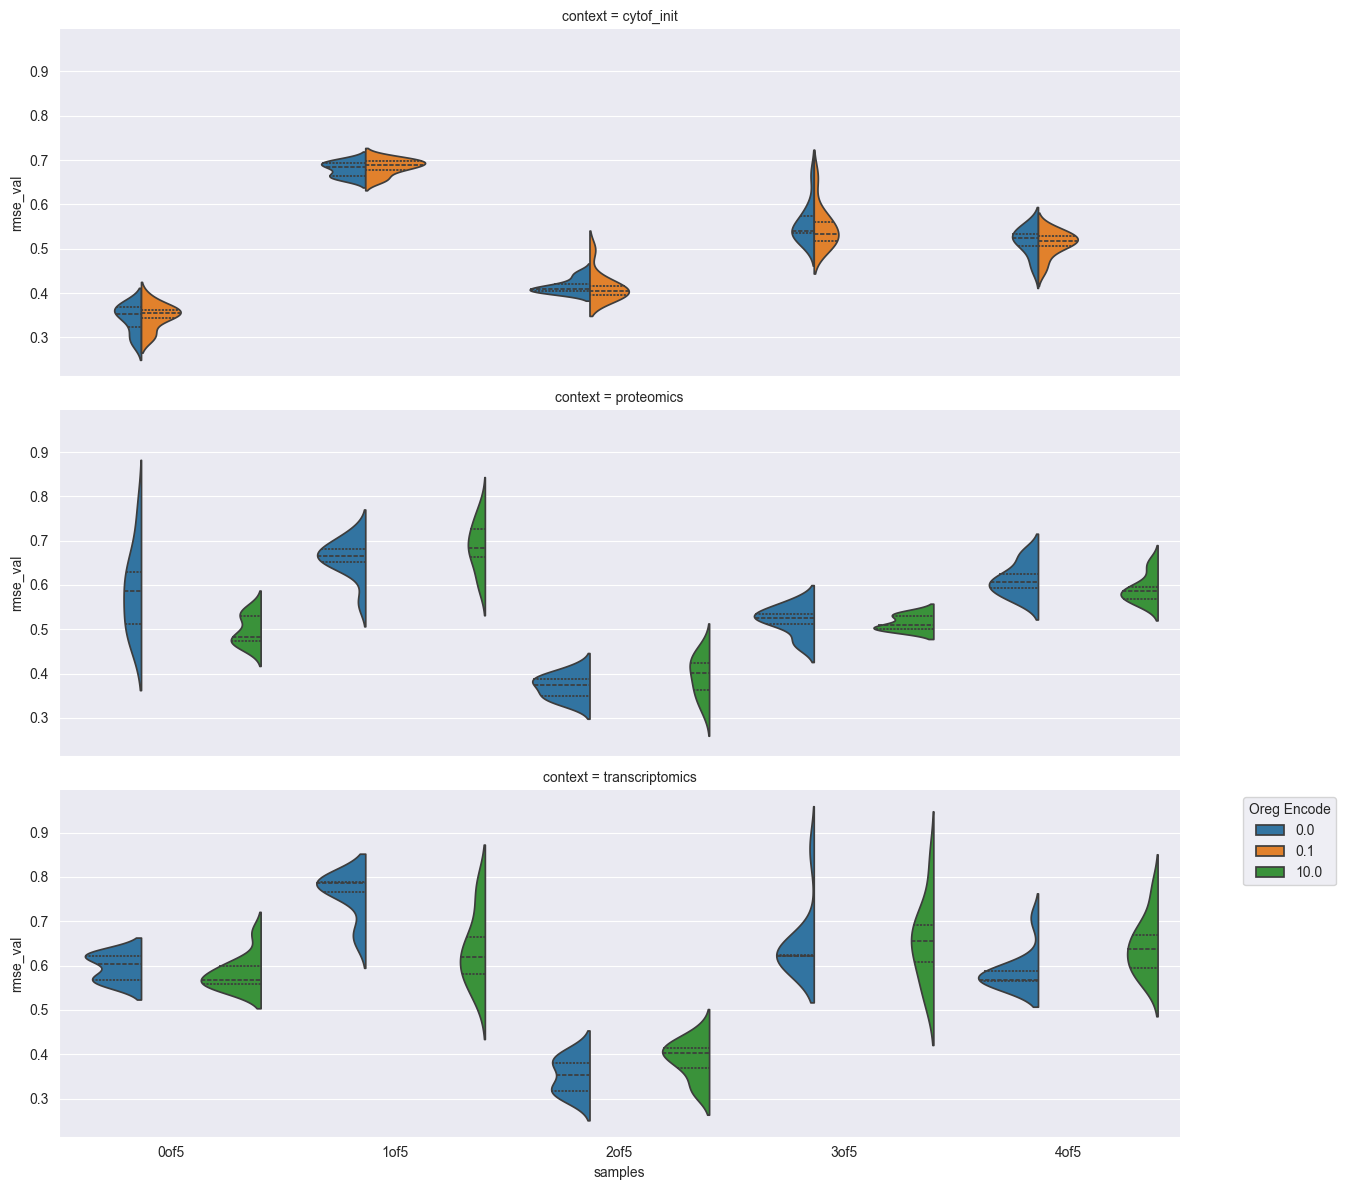

In [26]:
comparison_df = pd.concat([no_reg, optimal_reg])
g = sns.FacetGrid(
    comparison_df,
    row="context",
    row_order=sorted(comparison_df["context"].unique()),
    height=4,
    aspect=3
)
g.map_dataframe(
    sns.violinplot,
    x="samples",
    order=sorted(comparison_df["samples"].unique()),
    y="rmse_val",
    hue="oreg_encode",
    hue_order=sorted(comparison_df.oreg_encode.unique()),
    split=True,
    inner="quartile",
    palette="tab10"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Oreg Encode")

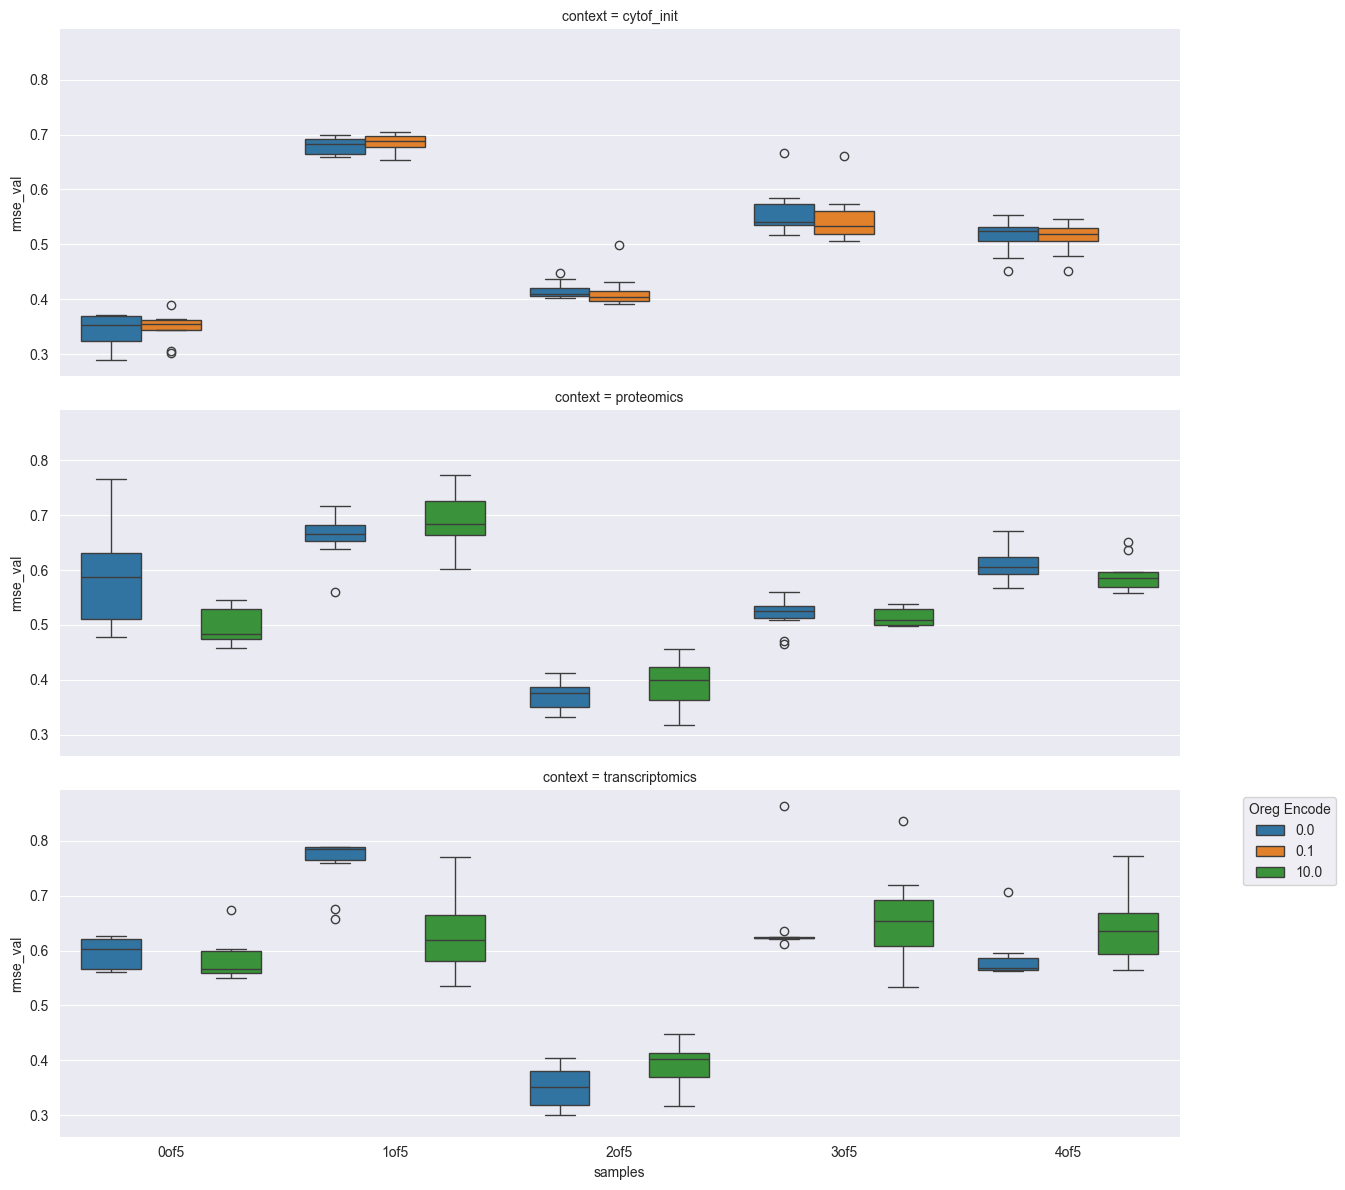

In [27]:
comparison_df = pd.concat([no_reg, optimal_reg])
g = sns.FacetGrid(
    comparison_df,
    row="context",
    row_order=sorted(comparison_df["context"].unique()),
    height=4,
    aspect=3
)
g.map_dataframe(
    sns.boxplot,
    x="samples",
    order=sorted(comparison_df["samples"].unique()),
    y="rmse_val",
    hue="oreg_encode",
    hue_order=sorted(comparison_df.oreg_encode.unique()),
    palette="tab10"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Oreg Encode")

In [213]:
for samples in comparison_df.samples.unique():
    kruskal_wallis_groups(
        comparison_df[comparison_df.samples == samples],
        target_metric="rmse_val",
        group_metric="oreg_encode"
    )

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.46, p-value=0.4963
Context: proteomics - Kruskal-Wallis H-test: H-statistic=1.46, p-value=0.2265
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=10.08, p-value=0.0015
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.14, p-value=0.7055
Context: proteomics - Kruskal-Wallis H-test: H-statistic=2.77, p-value=0.0963
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=4.81, p-value=0.0284
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.8703
Context: proteomics - Kruskal-Wallis H-test: H-statistic=5.49, p-value=0.0191
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=2.06, p-value=0.1509
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.81, p-value=0.3691
Context: proteomics - Kruskal-Wallis H-test: H-statistic=0.57, p-value=0.4497
Context: transcriptomics - Kruskal-Wallis H-test: H-statistic=0.69, p-value=0.4057
Context: cytof_init - Kruskal-Wallis H-test

There is pretty much no statistically significant difference, not even when looking at individual `samples` splits (only in `2of5` for `proteomics` where no regularisation wins; and in `0of5` and `1of5` for `transcriptomics` where regularisation performs clearly better). We can either drop the regularisation or use it.

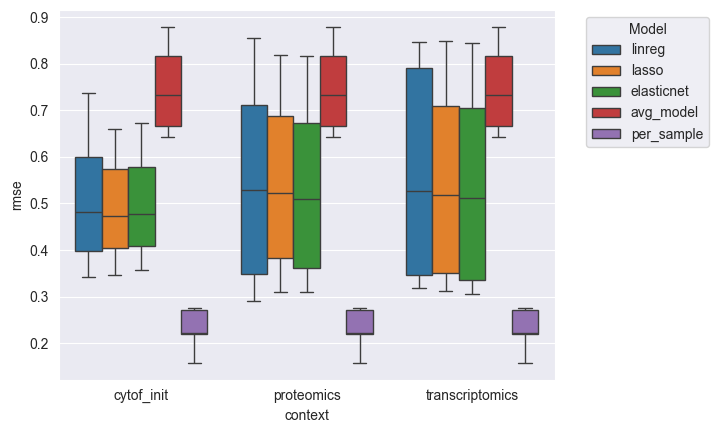

In [34]:
sns.boxplot(
    baseline_df[baseline_df.dataset == "val"],
    x="context",
    y="rmse",
    hue="mode"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")

In [72]:
optimal_reg = optimal_reg.assign(mode="DMM")
baseline_df_val = baseline_df[(baseline_df.dataset == "val") & (baseline_df.features_selection == "per_cv")]
baseline_df_val.rename(columns={"rmse": "rmse_val"}, inplace=True)
overall_df = pd.concat([optimal_reg, baseline_df_val])

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_50750/254322119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_df_val.rename(columns={"rmse": "rmse_val"}, inplace=True)


In [73]:
optimal_reg.groupby(["context", "samples"]).job.nunique()

context          samples
cytof_init       0of5        9
                 1of5       10
                 2of5        9
                 3of5        9
                 4of5       10
proteomics       0of5       10
                 1of5       10
                 2of5       10
                 3of5       10
                 4of5       10
transcriptomics  0of5       10
                 1of5       10
                 2of5       10
                 3of5       10
                 4of5       10
Name: job, dtype: int64

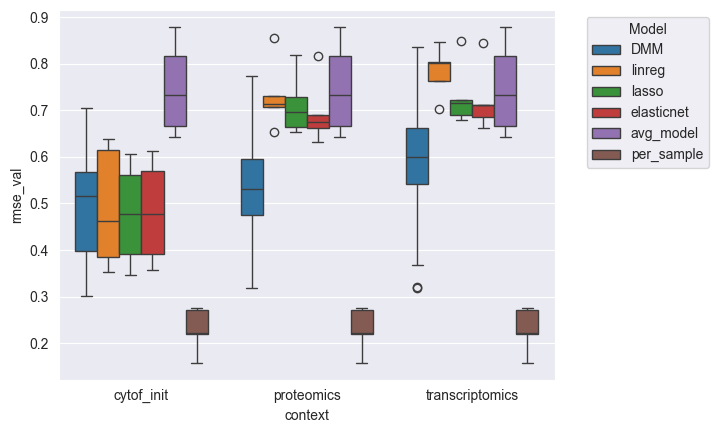

In [74]:
sns.boxplot(
    overall_df,
    x="context",
    order=sorted(overall_df["context"].unique()),
    y="rmse_val",
    hue="mode"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")

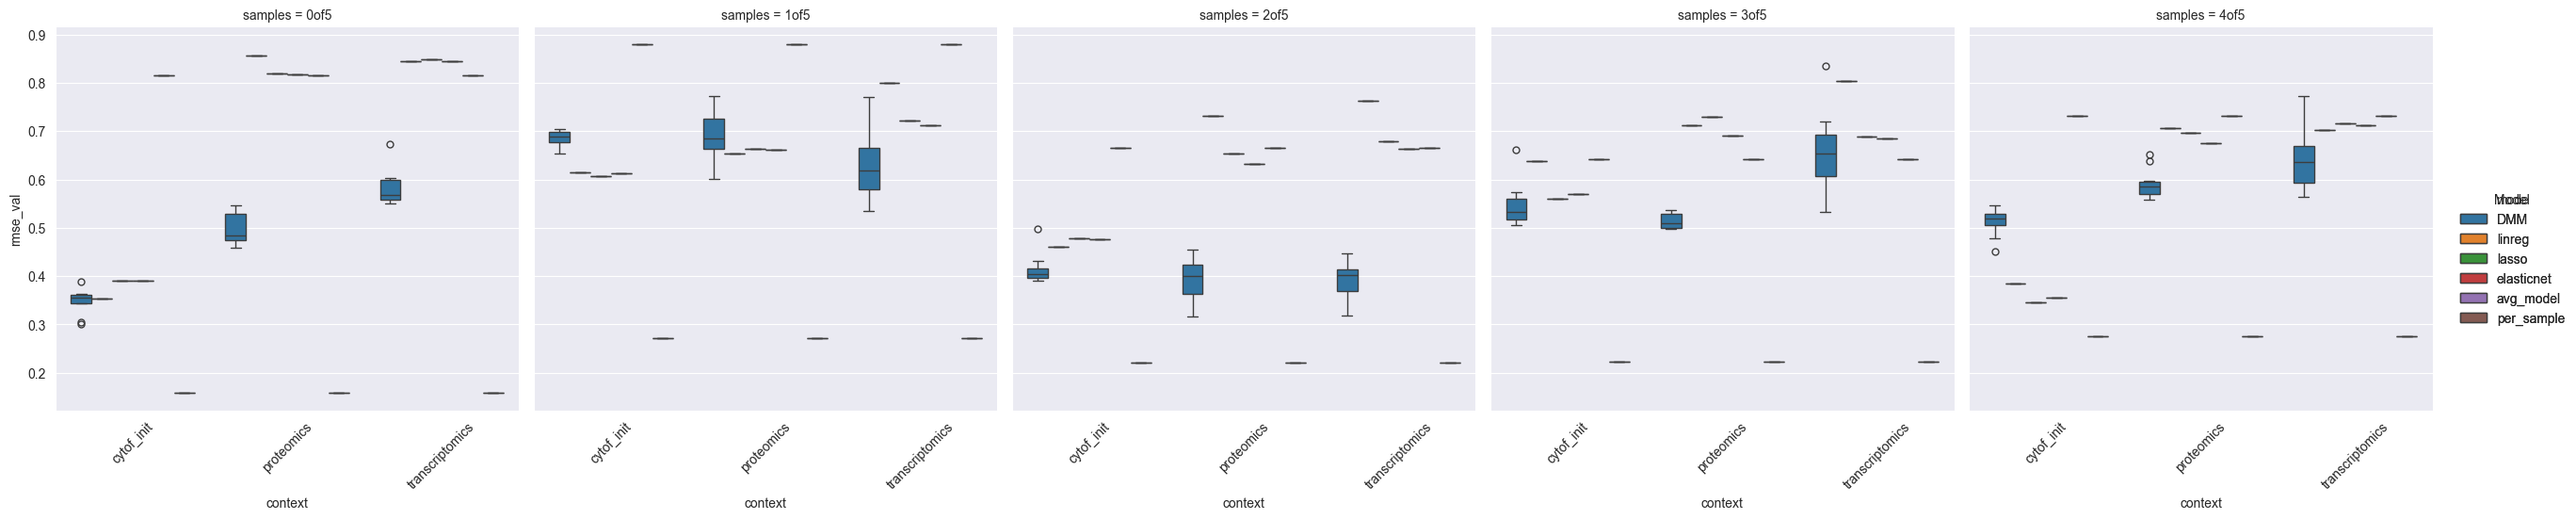

In [82]:
g = sns.catplot(
    data=overall_df,
    kind="box",
    x="context",
    y="rmse_val",
    hue="mode",
    col="samples",
    col_order=sorted(overall_df["samples"].unique()),
    order=sorted(overall_df["context"].unique()),
    palette="tab10"
)
g.add_legend(title="Model")
g.set_xticklabels(rotation=45)